# Named Entity Recognition (NER) with Word Embeddings

**Goal:** teach a model to find *named entities* in English text: people (PER), organisations (ORG), locations (LOC) and other names (MISC, e.g. nationalities or events).

For example, in *"Paul Kagame met the president of Kenya in Nairobi."* we want: `Paul Kagame` = PER, `Kenya` = LOC, `Nairobi` = LOC.

**Plan:**
1. Load and explore the CoNLL-2003 dataset
2. Baseline model **without** embeddings (the "before")
3. Model **with GloVe** embeddings (the "after")
4. Model with **FastText** embeddings, and how each handles unknown words
5. Compare all three and look at mistakes
6. Test on a small set of Rwandan sentences
7. Try the best model on new sentences

## Step 1: Load the dataset
We import the libraries we need. `datasets` downloads data from Hugging Face, and `seqeval` scores NER predictions per entity type.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import numpy as np
import pandas as pd
import datasets
from datasets import load_dataset

datasets.disable_progress_bars()  # keep the notebook output clean
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", 80)

We load **CoNLL-2003**, the standard English NER dataset (news articles from Reuters).

The original Hugging Face version (`conll2003`) uses an old "loading script" that newer versions of `datasets` refuse to run. So we load Hugging Face's automatic **parquet copy of the same dataset** (`eriktks/conll2003`, revision `refs/convert/parquet`). It has the same sentences, the same labels and the same official train / validation / test splits.

In [2]:
conll = load_dataset("eriktks/conll2003", revision="refs/convert/parquet")
conll

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

Each sentence is a list of **tokens** (words and punctuation) and a matching list of **NER tags**. The tags are stored as numbers, so we turn them back into their names (like `B-PER`).

In [3]:
TAG_NAMES = conll["train"].features["ner_tags"].feature.names
print("Tag set:", TAG_NAMES)

def to_sentences(split):
    """Return two lists: the tokens of each sentence and their tag names."""
    tokens = [list(t) for t in split["tokens"]]
    tags = [[TAG_NAMES[i] for i in seq] for seq in split["ner_tags"]]
    return tokens, tags

train_tokens, train_tags = to_sentences(conll["train"])
val_tokens, val_tags = to_sentences(conll["validation"])
test_tokens, test_tags = to_sentences(conll["test"])

for word, tag in zip(train_tokens[0], train_tags[0]):
    print(f"{word:10} {tag}")

Tag set: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
EU         B-ORG
rejects    O
German     B-MISC
call       O
to         O
boycott    O
British    B-MISC
lamb       O
.          O


### What do the tags mean? (the BIO format)
- `B-` means the **B**eginning of an entity, and `I-` means **I**nside it (the 2nd, 3rd... word of the same entity).
- `O` means **O**utside: the word is not part of any entity.

So "Paul Kagame" is tagged `B-PER I-PER`. There are 4 entity types: **PER** (person), **ORG** (organisation), **LOC** (location) and **MISC** (other names, like "German" or "World Cup").

**Note:** CoNLL-2003 has **no DATE type**. Words like "Friday" or "1996" are tagged `O`, so none of our models can learn to find dates.

### How big is each split?

In [4]:
def count_entities(tag_seqs):
    """Count entities by counting the B- tags (each entity starts with exactly one)."""
    counts = Counter(t[2:] for seq in tag_seqs for t in seq if t.startswith("B-"))
    return {etype: counts[etype] for etype in ["PER", "ORG", "LOC", "MISC"]}

rows = []
for name, toks, tags in [("train", train_tokens, train_tags),
                         ("validation", val_tokens, val_tags),
                         ("test", test_tokens, test_tags)]:
    row = {"split": name, "sentences": len(toks), "tokens": sum(len(s) for s in toks)}
    row.update(count_entities(tags))
    rows.append(row)

split_summary = pd.DataFrame(rows).set_index("split")
split_summary

,sentences,tokens,PER,ORG,LOC,MISC
split,,,,,,
train,14041,203621,6600,6321,7140,3438
validation,3250,51362,1842,1341,1837,922
test,3453,46435,1617,1661,1668,702


How common is each tag? Most tokens are `O`, so the dataset is very **imbalanced**. That's why we judge models with entity-level precision, recall and F1, not plain accuracy: a model that tags everything `O` would already have high accuracy.

In [5]:
tag_counts = Counter(t for seq in train_tags for t in seq)
tag_share = pd.DataFrame({"count": pd.Series(tag_counts)}).loc[TAG_NAMES]
tag_share["percent"] = (100 * tag_share["count"] / tag_share["count"].sum()).round(2)
tag_share

,count,percent
O,169578,83.28
B-PER,6600,3.24
I-PER,4528,2.22
B-ORG,6321,3.10
I-ORG,3704,1.82
B-LOC,7140,3.51
I-LOC,1157,0.57
B-MISC,3438,1.69
I-MISC,1155,0.57


## Step 2: Baseline model WITHOUT embeddings (the "before")

The model looks at **one word at a time** and guesses its tag. To help, we describe each word with a small dictionary of **features**:

- **Who the word is:** the word in lowercase, the previous word and the next word (so the model sees a bit of context), and the word's last 3 letters (its suffix, e.g. "-ing" or "-ese").
- **Spelling features:** does it start with a capital letter? Is it ALL CAPS? Does it contain a digit or a hyphen? Is it the first word of the sentence? We check the neighbours' capitals too.

Here the model knows words only as **separate labels**: "Kigali" and "Nairobi" are just two different, unrelated features. That's the "no embeddings" setup.

First, the spelling features. We'll **reuse exactly these** in the embedding models later.

In [6]:
def spelling_features(sentence, i):
    """Simple spelling (shape) features for the word at position i and its neighbours."""
    word = sentence[i]
    feats = {
        "is_title": word[:1].isupper(),        # starts with a capital letter
        "is_upper": word.isupper(),            # ALL CAPS, e.g. "WASAC"
        "is_lower": word.islower(),
        "has_digit": any(ch.isdigit() for ch in word),
        "has_hyphen": "-" in word,
        "is_punct": not any(ch.isalnum() for ch in word),
        "is_first": i == 0,                    # capitals at the start of a sentence mean less
        "is_last": i == len(sentence) - 1,
    }
    if i > 0:
        feats["prev_is_title"] = sentence[i - 1][:1].isupper()
        feats["prev_is_upper"] = sentence[i - 1].isupper()
    if i < len(sentence) - 1:
        feats["next_is_title"] = sentence[i + 1][:1].isupper()
        feats["next_is_upper"] = sentence[i + 1].isupper()
    return {name: float(value) for name, value in feats.items()}

def baseline_features(sentence, i):
    """Baseline: who the word is (word, neighbours, suffix) + spelling features."""
    feats = spelling_features(sentence, i)
    feats["word=" + sentence[i].lower()] = 1.0
    feats["suffix3=" + sentence[i][-3:].lower()] = 1.0
    feats["prev=" + (sentence[i - 1].lower() if i > 0 else "<START>")] = 1.0
    feats["next=" + (sentence[i + 1].lower() if i < len(sentence) - 1 else "<END>")] = 1.0
    return feats

print(baseline_features(["Paul", "Kagame", "visited", "Kigali", "."], 3))

{'is_title': 1.0, 'is_upper': 0.0, 'is_lower': 0.0, 'has_digit': 0.0, 'has_hyphen': 0.0, 'is_punct': 0.0, 'is_first': 0.0, 'is_last': 0.0, 'prev_is_title': 0.0, 'prev_is_upper': 0.0, 'next_is_title': 0.0, 'next_is_upper': 0.0, 'word=kigali': 1.0, 'suffix3=ali': 1.0, 'prev=visited': 1.0, 'next=.': 1.0}


Now we turn every word in every sentence into a feature dictionary. `DictVectorizer` then converts these dictionaries into a big table of numbers (one column per possible feature). This is the same "lots of mostly-zero columns" idea as TF-IDF in my spam classifier.

In [7]:
from sklearn.feature_extraction import DictVectorizer

def sentences_to_dicts(sentences, feature_fn):
    return [feature_fn(sent, i) for sent in sentences for i in range(len(sent))]

def flatten(tag_seqs):
    return [t for seq in tag_seqs for t in seq]

vectorizer = DictVectorizer()
X_train_base = vectorizer.fit_transform(sentences_to_dicts(train_tokens, baseline_features))
X_val_base = vectorizer.transform(sentences_to_dicts(val_tokens, baseline_features))
X_test_base = vectorizer.transform(sentences_to_dicts(test_tokens, baseline_features))
y_train = flatten(train_tags)

print("Training table:", X_train_base.shape[0], "words x", X_train_base.shape[1], "features")

Training table: 203621 words x 65784 features


### Training, and choosing a setting on the validation set
We use **Logistic Regression**, a simple and fast linear classifier. It has one main setting, `C`: a small `C` keeps the model simple, and a large `C` lets it fit the training data more closely.

We try a few values of `C` and keep the one with the best F1 on the **validation** set. We don't touch the test set while choosing, so the test score stays a fair "exam on unseen data".

`seqeval` scores at the **entity** level: "Paul Kagame" only counts as correct if *both* words get the right tags.

In [8]:
import time
from sklearn.linear_model import LogisticRegression
from seqeval.metrics import classification_report, f1_score

def regroup(flat_tags, sentences):
    """Cut a flat list of predicted tags back into one list per sentence."""
    out, pos = [], 0
    for sent in sentences:
        out.append(list(flat_tags[pos:pos + len(sent)]))
        pos += len(sent)
    return out

def train_with_validation(X_train, y_train, X_val, val_sentences, val_tags, Cs):
    """Train one model per C, report validation F1, return the best model."""
    best_model, best_f1 = None, -1
    for C in Cs:
        start = time.time()
        model = LogisticRegression(C=C, max_iter=1000)
        model.fit(X_train, y_train)
        val_f1 = f1_score(val_tags, regroup(model.predict(X_val), val_sentences))
        print(f"C={C:<6} validation F1 = {val_f1:.4f}   ({time.time() - start:.0f}s)")
        if val_f1 > best_f1:
            best_model, best_f1 = model, val_f1
    print("Best C:", best_model.C)
    return best_model

baseline_model = train_with_validation(X_train_base, y_train, X_val_base,
                                       val_tokens, val_tags, Cs=[0.1, 1, 10, 100])

C=0.1    validation F1 = 0.7436   (26s)
C=1      validation F1 = 0.8258   (38s)
C=10     validation F1 = 0.8376   (39s)
C=100    validation F1 = 0.8319   (20s)
Best C: 10


### Test-set results for the baseline
Now we run the chosen model **once** on the test set. For each entity type:
- **Precision:** of the entities the model found, how many were right?
- **Recall:** of the real entities, how many did the model find?
- **F1:** a single score that balances the two.

In [9]:
baseline_test_pred = regroup(baseline_model.predict(X_test_base), test_tokens)
print(classification_report(test_tags, baseline_test_pred, digits=3))

results = {}  # we collect every model's test report here for the final comparison
results["Baseline (no embeddings)"] = classification_report(test_tags, baseline_test_pred, output_dict=True)

              precision    recall  f1-score   support

         LOC      0.801     0.815     0.808      1668
        MISC      0.730     0.775     0.752       702
         ORG      0.627     0.650     0.638      1661
         PER      0.711     0.811     0.758      1617

   micro avg      0.715     0.760     0.737      5648
   macro avg      0.717     0.763     0.739      5648
weighted avg      0.715     0.760     0.737      5648



## Step 3: NER WITH GloVe embeddings (the "after")

Now we replace "who the word is" with a **word embedding**: a list of numbers learned from huge amounts of text, where words used in similar ways get similar numbers. With embeddings, "Kigali" and "Nairobi" look *similar* to the model, so what it learns about one can help with the other.

We use the same small **GloVe** vectors as in `word_embeddings.ipynb`: 50 numbers per word, trained on Wikipedia and news.

In [10]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-50")
print("GloVe vocabulary:", len(glove), "words,", glove.vector_size, "numbers per word")
print("Similar to 'kigali':", [w for w, _ in glove.most_similar("kigali", topn=5)])

GloVe vocabulary: 400000 words, 50 numbers per word
Similar to 'kigali': ['kinshasa', 'rwanda', 'goma', 'bujumbura', 'dili']


### Building the features
For each word we put three vectors side by side: **previous word + this word + next word** (3 x 50 = 150 numbers), so the model sees some context.

- GloVe only contains **lowercase** words, so we look words up in lowercase.
- If a word isn't in GloVe (it's **out of vocabulary**, or OOV), we use a vector of zeros, which means "no information".

**Why we still add the spelling features:** lowercasing throws away capital letters, and capitals are one of the strongest clues in English NER ("Apple" the company vs "apple" the fruit). So we add back the **exact same spelling features as the baseline**. That way the only thing that changes between the two models is how the word itself is represented: a separate label (baseline) or an embedding (this model).

In [11]:
def embedding_features(sentences, lookup, dim):
    """Return a table with one row per word: [prev vector, word vector, next vector, spelling features].

    `lookup(word)` returns a vector, or None if the embedding doesn't know the word.
    """
    n_words = sum(len(s) for s in sentences)
    vectors = np.zeros((n_words, 3 * dim), dtype=np.float32)
    spelling = []
    row = 0
    for sent in sentences:
        sent_vecs = [lookup(w) for w in sent]
        for i in range(len(sent)):
            for slot, j in enumerate([i - 1, i, i + 1]):          # previous, current, next
                if 0 <= j < len(sent) and sent_vecs[j] is not None:
                    vectors[row, slot * dim:(slot + 1) * dim] = sent_vecs[j]
            spelling.append(spelling_features(sent, i))
            row += 1
    spelling = spelling_vectorizer.transform(spelling).toarray().astype(np.float32)
    return np.hstack([vectors, spelling])

def glove_lookup(word):
    word = word.lower()
    return glove[word] if word in glove else None

# Fixed list of spelling-feature columns (the same features the baseline used)
spelling_vectorizer = DictVectorizer().fit(sentences_to_dicts(train_tokens, spelling_features))

### How many words does GloVe not know?
We count out-of-vocabulary (OOV) words in each split, both as a share of all tokens and as a share of distinct words.

In [12]:
def oov_report(lookup, name):
    rows = []
    for split, toks in [("train", train_tokens), ("validation", val_tokens), ("test", test_tokens)]:
        all_words = [w for s in toks for w in s]
        unique = set(all_words)
        oov_tokens = sum(lookup(w) is None for w in all_words)
        oov_unique = [w for w in unique if lookup(w) is None]
        rows.append({"split": split,
                     "OOV tokens": oov_tokens, "OOV % of tokens": round(100 * oov_tokens / len(all_words), 2),
                     "OOV distinct words": len(oov_unique),
                     "OOV % of distinct words": round(100 * len(oov_unique) / len(unique), 2),
                     "examples": ", ".join(sorted(oov_unique)[:8])})
    print(name)
    return pd.DataFrame(rows).set_index("split")

oov_report(glove_lookup, "GloVe out-of-vocabulary words")

GloVe out-of-vocabulary words


,OOV tokens,OOV % of tokens,OOV distinct words,OOV % of distinct words,examples
split,,,,,
train,4632,2.27,2614,11.07,"**General, *INDICES, *Name, *Note, ++359-2, +0,2, +0.0, +0.05"
validation,1054,2.05,673,6.75,"+0.089, +0.237, +0.300, +0.435, +0.578, +1.660, +10.436, +27-11"
test,1331,2.87,842,8.87,"*1995, *from, +$0.50, +212-859-1628, +371, +392, +44-171-542, +48"


Now we build the tables. We also **standardise** each column (shift and scale it so it has mean 0 and spread 1). Then the GloVe numbers and the 0/1 spelling features are on the same scale, which helps Logistic Regression train well.

In [13]:
from sklearn.preprocessing import StandardScaler

glove_scaler = StandardScaler()
X_train_glove = glove_scaler.fit_transform(embedding_features(train_tokens, glove_lookup, glove.vector_size))
X_val_glove = glove_scaler.transform(embedding_features(val_tokens, glove_lookup, glove.vector_size))
X_test_glove = glove_scaler.transform(embedding_features(test_tokens, glove_lookup, glove.vector_size))
print("Training table:", X_train_glove.shape[0], "words x", X_train_glove.shape[1], "features")
print(f"(baseline had {X_train_base.shape[1]} mostly-zero columns; this one has {X_train_glove.shape[1]} dense columns)")

Training table: 203621 words x 162 features
(baseline had 65784 mostly-zero columns; this one has 162 dense columns)


### Training: same classifier, C chosen on validation
Exactly the same procedure as the baseline: Logistic Regression, try several values of `C`, and keep the best on the validation set.

In [14]:
glove_model = train_with_validation(X_train_glove, y_train, X_val_glove,
                                    val_tokens, val_tags, Cs=[0.1, 1, 10, 100])

C=0.1    validation F1 = 0.7759   (6s)
C=1      validation F1 = 0.7743   (8s)
C=10     validation F1 = 0.7725   (6s)
C=100    validation F1 = 0.7767   (11s)
Best C: 100


### Test-set results for GloVe
We evaluate **once** on the test set with the same seqeval report.

In [15]:
glove_test_pred = regroup(glove_model.predict(X_test_glove), test_tokens)
print(classification_report(test_tags, glove_test_pred, digits=3))
results["GloVe (50d)"] = classification_report(test_tags, glove_test_pred, output_dict=True)

              precision    recall  f1-score   support

         LOC      0.752     0.836     0.792      1668
        MISC      0.577     0.687     0.627       702
         ORG      0.611     0.647     0.628      1661
         PER      0.863     0.885     0.874      1617

   micro avg      0.718     0.776     0.746      5648
   macro avg      0.701     0.763     0.730      5648
weighted avg      0.721     0.776     0.747      5648



### Two more classifiers on the same GloVe features
Logistic Regression draws **straight lines** between the tags. With embeddings, the useful patterns may be curvier: for example, "a capitalised word whose vector sits near city names, right after 'in'". So we also try two models that can learn curved, non-linear patterns. All three get exactly the same GloVe features.

- **Random Forest:** many decision trees, each asking yes/no questions like "is number 17 of the vector above 0.3?", and the trees vote. It can combine features in non-linear ways and needs no scaling. Settings: 100 trees, at least 5 words per leaf (to keep memory use down on 200k words), `n_jobs=-1` to use every CPU core.
- **MLP (small neural network):** one hidden layer of 256 "neurons" that learns its own combinations of the embedding numbers before choosing a tag. Neural networks are the usual partner for dense embeddings. `early_stopping=True` holds back 10% of the training words and stops training when the score on them stops improving, which saves time and avoids overfitting.

We didn't tune these settings: we picked reasonable defaults once, for both GloVe and FastText. Only Logistic Regression's `C` was tuned. All three models are trained on the **full** training set.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

def make_random_forest():
    return RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1, random_state=42)

def make_mlp():
    return MLPClassifier(hidden_layer_sizes=(256,), early_stopping=True, max_iter=50, random_state=42)

val_scores = {}  # overall validation F1 of each model, used to choose the best one

def fit_and_report(name, model, X_train, X_val, X_test):
    """Train, print validation F1 and the test-set seqeval report, store the results."""
    start = time.time()
    model.fit(X_train, y_train)
    val_scores[name] = f1_score(val_tags, regroup(model.predict(X_val), val_tokens))
    test_pred = regroup(model.predict(X_test), test_tokens)
    results[name] = classification_report(test_tags, test_pred, output_dict=True)
    print(f"{name}: validation F1 = {val_scores[name]:.4f}   ({time.time() - start:.0f}s)\n")
    print(classification_report(test_tags, test_pred, digits=3))
    return test_pred

# Store validation scores for the two models we already trained (no retraining happens here)
val_scores["Baseline (no embeddings)"] = f1_score(val_tags, regroup(baseline_model.predict(X_val_base), val_tokens))
val_scores["GloVe (50d)"] = f1_score(val_tags, regroup(glove_model.predict(X_val_glove), val_tokens))
# Give the GloVe Logistic Regression a clearer name, now that there are three GloVe models
results["GloVe + LogReg"] = results.pop("GloVe (50d)")
val_scores["GloVe + LogReg"] = val_scores.pop("GloVe (50d)")
test_preds = {"Baseline (no embeddings)": baseline_test_pred, "GloVe + LogReg": glove_test_pred}
models = {"Baseline (no embeddings)": baseline_model, "GloVe + LogReg": glove_model}
print({name: round(score, 4) for name, score in val_scores.items()})

{'Baseline (no embeddings)': np.float64(0.8376), 'GloVe + LogReg': np.float64(0.7767)}


**Random Forest with GloVe features:**

In [17]:
models["GloVe + RandomForest"] = make_random_forest()
test_preds["GloVe + RandomForest"] = fit_and_report("GloVe + RandomForest", models["GloVe + RandomForest"],
                                                    X_train_glove, X_val_glove, X_test_glove)

GloVe + RandomForest: validation F1 = 0.8680   (46s)

              precision    recall  f1-score   support

         LOC      0.846     0.887     0.866      1668
        MISC      0.776     0.704     0.738       702
         ORG      0.713     0.764     0.738      1661
         PER      0.829     0.907     0.866      1617

   micro avg      0.793     0.834     0.813      5648
   macro avg      0.791     0.815     0.802      5648
weighted avg      0.793     0.834     0.812      5648



**MLP (neural network) with GloVe features:**

In [18]:
models["GloVe + MLP"] = make_mlp()
test_preds["GloVe + MLP"] = fit_and_report("GloVe + MLP", models["GloVe + MLP"],
                                           X_train_glove, X_val_glove, X_test_glove)
print("MLP stopped after", models["GloVe + MLP"].n_iter_, "passes over the training data")

GloVe + MLP: validation F1 = 0.8668   (58s)

              precision    recall  f1-score   support

         LOC      0.810     0.905     0.855      1668
        MISC      0.654     0.731     0.690       702
         ORG      0.698     0.769     0.732      1661
         PER      0.875     0.892     0.883      1617

   micro avg      0.774     0.840     0.806      5648
   macro avg      0.759     0.824     0.790      5648
weighted avg      0.776     0.840     0.806      5648

MLP stopped after 27 passes over the training data


## Step 4: GloVe vs FastText

**FastText** (from Facebook) learns vectors for **pieces of words** (character n-grams like `<ki`, `kic`, `icu`, ...) as well as whole words. A word's vector is built from its pieces, so in principle FastText can make a vector even for a word it **never saw**, like *Kicukiro*, by adding up the vectors of its pieces.

We load the pre-trained `fasttext-wiki-news-subwords-300` vectors through gensim: 1 million words, 300 numbers each, trained on Wikipedia and news. **It's a ~1 GB download**, so the first run takes a while.

**Important catch:** this gensim download contains only the finished **whole-word** vectors, not the table of word-piece vectors. So in practice it behaves like a big lookup table: words that aren't in its 1 million entries get **nothing**, just like GloVe. The full model with the word-piece table is a 4.5 GB download (about 7 GB unzipped) and needs more memory than this laptop has free. We'll still show how word pieces work, using a small FastText model we train ourselves (below).

To save memory, we load the vectors once, save them in gensim's own format in `data/embeddings/` (ignored by git, so they're never committed), and then open that file **memory-mapped**: the vectors stay on disk and are only read when needed.

In [19]:
import gc
import os
from gensim.models import KeyedVectors

FASTTEXT_PATH = "../data/embeddings/fasttext-wiki-news-subwords-300.kv"
if not os.path.exists(FASTTEXT_PATH):
    os.makedirs(os.path.dirname(FASTTEXT_PATH), exist_ok=True)
    api.load("fasttext-wiki-news-subwords-300").save(FASTTEXT_PATH)  # ~1 GB download, first run only
    gc.collect()
fasttext = KeyedVectors.load(FASTTEXT_PATH, mmap="r")
print("FastText vocabulary:", len(fasttext), "words,", fasttext.vector_size, "numbers per word")
print("Has the word-piece table?", hasattr(fasttext, "vectors_ngrams"))

[=================================================-] 98.9% 947.4/958.4MB downloaded
FastText vocabulary: 999999 words, 300 numbers per word
Has the word-piece table? False


### Looking words up in FastText
Unlike GloVe, these FastText vectors are **case-sensitive** ("Apple" and "apple" are different entries). So we try the word exactly as written first, then fall back to lowercase.

In [20]:
def fasttext_lookup(word):
    for form in (word, word.lower()):
        if form in fasttext.key_to_index:
            return fasttext[form]
    return None

oov_report(fasttext_lookup, "FastText out-of-vocabulary words")

FastText out-of-vocabulary words


,OOV tokens,OOV % of tokens,OOV distinct words,OOV % of distinct words,examples
split,,,,,
train,4661,2.29,2584,10.94,"**, **General, *INDICES, *Name, *Note, ++359-2, +0,2, +0.0"
validation,1070,2.08,699,7.01,"+0.089, +0.237, +0.300, +0.435, +0.578, +1, +1.660, +10.436"
test,1345,2.90,858,9.04,"*1995, *from, +$0.50, +1, +212-859-1628, +31, +32, +371"


### How do the two embeddings handle unknown words?
We check some Rwandan place names, organisations and people, plus a couple of well-known words for comparison. `True` means the embedding has a vector for the word.

In [21]:
probe_words = ["Kigali", "Nairobi", "Kicukiro", "Gikondo", "Nyarugenge", "Kimironko", "Remera",
               "Musanze", "Huye", "WASAC", "REG", "Kagame", "Rwanda"]
probe = pd.DataFrame({
    "in GloVe (lowercased)": [w.lower() in glove for w in probe_words],
    "in FastText (as written or lowercased)": [fasttext_lookup(w) is not None for w in probe_words],
}, index=probe_words)
probe

,in GloVe (lowercased),in FastText (as written or lowercased)
Kigali,True,True
Nairobi,True,True
Kicukiro,False,True
Gikondo,False,True
Nyarugenge,False,True
Kimironko,False,False
Remera,False,False
Musanze,False,True
Huye,True,True
WASAC,False,False


**What the table shows:** FastText's vocabulary is 2.5 times bigger than GloVe's (1 million words vs 400,000) and it was trained on more web text, so it **does** know several Rwandan places as whole words: Kicukiro, Gikondo, Nyarugenge and Musanze. GloVe knows none of these. Both miss Kimironko, Remera and WASAC, and because this FastText file has no word-piece table, those words get a zero vector in both models.

What are the nearest neighbours of these words? Sensible neighbours suggest the embedding has learned something real about the word.

In [22]:
for word in ["Kigali", "Kicukiro", "Gikondo"]:
    g = [w for w, _ in glove.most_similar(word.lower(), topn=5)] if word.lower() in glove else "not in GloVe"
    form = next((f for f in (word, word.lower()) if f in fasttext.key_to_index), None)
    f = [w for w, _ in fasttext.most_similar(form, topn=5)] if form else "not in FastText"
    print(f"{word}\n  GloVe:    {g}\n  FastText: {f}")

Kigali
  GloVe:    ['kinshasa', 'rwanda', 'goma', 'bujumbura', 'dili']
  FastText: ['Rwanda', 'Bujumbura', 'Kampala', 'Kinshasa', 'Bukavu']
Kicukiro
  GloVe:    not in GloVe
  FastText: ['Epukiro', 'Brikama', 'Muliro', 'Nyarugenge', 'Hoima']
Gikondo
  GloVe:    not in GloVe
  FastText: ['Matondo', 'Dondo', 'Jondo', 'Mulondo', 'Sismondo']


### Seeing word pieces (subwords) in action
To show *how* FastText builds vectors for unseen words, we train a **small FastText model with word pieces** on the CoNLL training sentences (it's only for this demo, not for the NER models). Every word is broken into pieces of 3 to 6 characters, with `<` and `>` marking the start and end of the word.

In [23]:
from gensim.models import FastText

small_ft = FastText(sentences=train_tokens, vector_size=50, window=5, min_count=2,
                    min_n=3, max_n=6, epochs=10, seed=42, workers=4)

def pieces(word, min_n=3, max_n=6):
    w = f"<{word}>"
    return [w[i:i + n] for n in range(min_n, max_n + 1) for i in range(len(w) - n + 1)]

print("Pieces of 'Kicukiro' (first 12):", pieces("Kicukiro")[:12], "...")
for word in ["Kicukiro", "Gikondo"]:
    print(f"\n{word}: in the small model's vocabulary? {word in small_ft.wv.key_to_index}")
    print("  ...but it still gets a vector built from its pieces. Vector starts:", np.round(small_ft.wv[word][:4], 3))
    print("  Nearest known words:", [w for w, _ in small_ft.wv.most_similar(word, topn=5)])

Pieces of 'Kicukiro' (first 12): ['<Ki', 'Kic', 'icu', 'cuk', 'uki', 'kir', 'iro', 'ro>', '<Kic', 'Kicu', 'icuk', 'cuki'] ...

Kicukiro: in the small model's vocabulary? False
  ...but it still gets a vector built from its pieces. Vector starts: [ 0.111  0.1   -0.126 -0.012]
  Nearest known words: ['Opava', 'Vavuniya', 'Shabwa', 'Kaucuk', 'Zizkov']

Gikondo: in the small model's vocabulary? False
  ...but it still gets a vector built from its pieces. Vector starts: [ 0.154  0.123 -0.205 -0.034]
  Nearest known words: ['Slams', 'Takeishi', 'Venezuela', 'Yasushi', 'Zubair']


The small model has never seen "Kicukiro" or "Gikondo", but it can still build vectors for them from their pieces, while GloVe can only say "not found". The neighbours show the limits, though. Its neighbours are words that **share spelling pieces** ("Kaucuk" shares `cuk`), not words with similar meanings: Gikondo's neighbours ("Slams", "Venezuela") make no sense. The model was trained on only 14,000 sentences, which is far too little text to give the pieces real meaning. Compare the big FastText model above, which put Kicukiro next to Nyarugenge, another district of Kigali, because it learned Kicukiro as a whole word from a huge amount of text. That's why subword models are promising for my capstone (Kinyarwanda words share many prefixes and suffixes).

### Training the same three models on FastText features
Same recipe as GloVe: previous + current + next word vectors (3 x 300 = 900 numbers), plus the same spelling features, then standardised.

In [24]:
# Free the GloVe training table first to save memory (the trained GloVe models are kept)
del X_train_glove
gc.collect()

fasttext_scaler = StandardScaler()
X_train_ft = fasttext_scaler.fit_transform(embedding_features(train_tokens, fasttext_lookup, fasttext.vector_size))
X_val_ft = fasttext_scaler.transform(embedding_features(val_tokens, fasttext_lookup, fasttext.vector_size))
X_test_ft = fasttext_scaler.transform(embedding_features(test_tokens, fasttext_lookup, fasttext.vector_size))
print("Training table:", X_train_ft.shape[0], "words x", X_train_ft.shape[1], "features,", X_train_ft.dtype)

Training table: 203621 words x 912 features, float32


**Logistic Regression with FastText features** (C chosen on validation, as before). We also try smaller values (`C=0.01` and `C=0.001`), because on the first try the best value was the smallest one we had tested (0.1).

In [29]:
ft_logreg = train_with_validation(X_train_ft, y_train, X_val_ft, val_tokens, val_tags, Cs=[0.001, 0.01, 0.1, 1, 10, 100])
models["FastText + LogReg"] = ft_logreg
val_scores["FastText + LogReg"] = f1_score(val_tags, regroup(ft_logreg.predict(X_val_ft), val_tokens))
test_preds["FastText + LogReg"] = regroup(ft_logreg.predict(X_test_ft), test_tokens)
results["FastText + LogReg"] = classification_report(test_tags, test_preds["FastText + LogReg"], output_dict=True)
print(classification_report(test_tags, test_preds["FastText + LogReg"], digits=3))

C=0.001  validation F1 = 0.8514   (28s)
C=0.01   validation F1 = 0.8631   (40s)
C=0.1    validation F1 = 0.8493   (236s)
C=1      validation F1 = 0.8410   (38s)
C=10     validation F1 = 0.8360   (48s)
C=100    validation F1 = 0.8337   (56s)
Best C: 0.01
              precision    recall  f1-score   support

         LOC      0.822     0.885     0.853      1668
        MISC      0.674     0.754     0.711       702
         ORG      0.697     0.759     0.727      1661
         PER      0.897     0.912     0.904      1617

   micro avg      0.786     0.839     0.812      5648
   macro avg      0.772     0.827     0.799      5648
weighted avg      0.788     0.839     0.813      5648



**Random Forest with FastText features:**

In [26]:
models["FastText + RandomForest"] = make_random_forest()
test_preds["FastText + RandomForest"] = fit_and_report("FastText + RandomForest", models["FastText + RandomForest"],
                                                       X_train_ft, X_val_ft, X_test_ft)

FastText + RandomForest: validation F1 = 0.8594   (191s)

              precision    recall  f1-score   support

         LOC      0.844     0.865     0.854      1668
        MISC      0.751     0.695     0.722       702
         ORG      0.705     0.732     0.718      1661
         PER      0.861     0.892     0.877      1617

   micro avg      0.797     0.812     0.805      5648
   macro avg      0.790     0.796     0.793      5648
weighted avg      0.796     0.812     0.804      5648



**MLP (neural network) with FastText features:**

In [27]:
models["FastText + MLP"] = make_mlp()
test_preds["FastText + MLP"] = fit_and_report("FastText + MLP", models["FastText + MLP"],
                                              X_train_ft, X_val_ft, X_test_ft)
print("MLP stopped after", models["FastText + MLP"].n_iter_, "passes over the training data")

FastText + MLP: validation F1 = 0.8726   (702s)

              precision    recall  f1-score   support

         LOC      0.821     0.895     0.856      1668
        MISC      0.709     0.751     0.729       702
         ORG      0.713     0.791     0.750      1661
         PER      0.867     0.919     0.892      1617

   micro avg      0.788     0.853     0.819      5648
   macro avg      0.777     0.839     0.807      5648
weighted avg      0.788     0.853     0.819      5648

MLP stopped after 34 passes over the training data


## Step 5: Compare and analyse

### Comparison table
One row per model. The four entity columns and "overall" are **test-set F1** scores. "Overall" is the micro-average, which counts every entity equally. The last column is the overall F1 on the **validation** set.

We pick the best model by **overall validation F1**. Picking on the test set would turn our final exam into practice questions, and its score would look better than it really is. The test F1 column shows how each choice held up on unseen data.

In [30]:
ENTITY_TYPES = ["PER", "ORG", "LOC", "MISC"]

def family(name):
    return "Baseline" if name.startswith("Baseline") else name.split(" + ")[0]

comparison = pd.DataFrame({
    name: {**{etype: report[etype]["f1-score"] for etype in ENTITY_TYPES},
           "overall F1 (test)": report["micro avg"]["f1-score"],
           "overall F1 (validation)": val_scores[name]}
    for name, report in results.items()
}).T.round(3)
comparison

,PER,ORG,LOC,MISC,overall F1 (test),overall F1 (validation)
Baseline (no embeddings),0.758,0.638,0.808,0.752,0.737,0.838
GloVe + LogReg,0.874,0.628,0.792,0.627,0.746,0.777
GloVe + RandomForest,0.866,0.738,0.866,0.738,0.813,0.868
GloVe + MLP,0.883,0.732,0.855,0.690,0.806,0.867
FastText + LogReg,0.904,0.727,0.853,0.711,0.812,0.863
FastText + RandomForest,0.877,0.718,0.854,0.722,0.805,0.859
FastText + MLP,0.892,0.750,0.856,0.729,0.819,0.873


Precision and recall per entity type for every model (test set):

In [37]:
detail = pd.DataFrame({
    (name, etype): {"precision": results[name][etype]["precision"],
                    "recall": results[name][etype]["recall"],
                    "f1": results[name][etype]["f1-score"]}
    for name in results for etype in ENTITY_TYPES + ["micro avg"]
}).T.round(3)
detail.unstack(level=1).swaplevel(axis=1).sort_index(axis=1, level=0)[["PER", "ORG", "LOC", "MISC", "micro avg"]].loc[list(results)]

PER                     ORG                     LOC                    MISC                  micro avg                 
                             f1 precision recall     f1 precision recall     f1 precision recall     f1 precision recall        f1 precision recall
Baseline (no embeddings)  0.758     0.711  0.811  0.638     0.627  0.650  0.808     0.801  0.815  0.752     0.730  0.775     0.737     0.715  0.760
GloVe + LogReg            0.874     0.863  0.885  0.628     0.611  0.647  0.792     0.752  0.836  0.627     0.577  0.687     0.746     0.718  0.776
GloVe + RandomForest      0.866     0.829  0.907  0.738     0.713  0.764  0.866     0.846  0.887  0.738     0.776  0.704     0.813     0.793  0.834
GloVe + MLP               0.883     0.875  0.892  0.732     0.698  0.769  0.855     0.810  0.905  0.690     0.654  0.731     0.806     0.774  0.840
FastText + LogReg         0.904     0.897  0.912  0.727     0.697  0.759  0.853     0.822  0.885  0.711     0.674  0.754     0.812     0.786  0.839
FastText + RandomForest   0.877     0.861  0.892  0.718     0.705  0.732  0.854     0.844  0.865  0.722     0.751  0.695     0.805     0.797  0.812
FastText + MLP            0.892     0.867  0.919  0.750     0.713  0.791  0.856     0.821  0.895  0.729     0.709  0.751     0.819     0.788  0.853

### Choosing the best models

In [32]:
best_overall = comparison["overall F1 (validation)"].idxmax()
best_glove = comparison.loc[[n for n in comparison.index if family(n) == "GloVe"], "overall F1 (validation)"].idxmax()
best_fasttext = comparison.loc[[n for n in comparison.index if family(n) == "FastText"], "overall F1 (validation)"].idxmax()
best_by_test = comparison["overall F1 (test)"].idxmax()

print("Best model overall (by validation F1):", best_overall)
print("Best GloVe model:                     ", best_glove)
print("Best FastText model:                  ", best_fasttext)
print("Best model if we had looked at test F1:", best_by_test)

Best model overall (by validation F1): FastText + MLP
Best GloVe model:                      GloVe + RandomForest
Best FastText model:                   FastText + MLP
Best model if we had looked at test F1: FastText + MLP


### Chart: F1 per entity type for every model
One small panel per entity type, so each set of bars is easy to compare. The colour shows the embedding family: gray = baseline, blue = GloVe, orange = FastText.

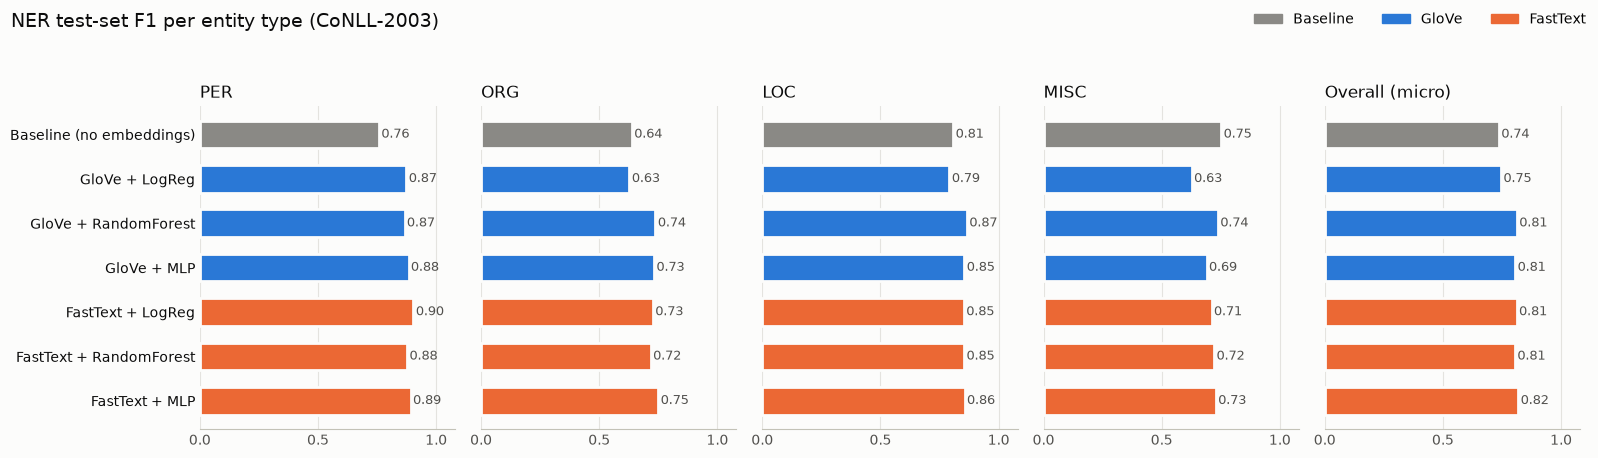

In [33]:
import matplotlib.pyplot as plt

COLORS = {"Baseline": "#8a8985", "GloVe": "#2a78d6", "FastText": "#eb6834"}
panels = ENTITY_TYPES + ["overall F1 (test)"]
order = list(comparison.index)

fig, axes = plt.subplots(1, len(panels), figsize=(16, 4.6), sharey=True)
fig.patch.set_facecolor("#fcfcfb")
for ax, col in zip(axes, panels):
    ax.set_facecolor("#fcfcfb")
    values = comparison.loc[order, col]
    ax.barh(range(len(order)), values, height=0.62, color=[COLORS[family(n)] for n in order],
            edgecolor="#fcfcfb", linewidth=2)
    for y, v in enumerate(values):
        ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=9, color="#52514e")
    ax.set_title("Overall (micro)" if col.startswith("overall") else col, fontsize=12, color="#0b0b0b", loc="left")
    ax.set_xlim(0, 1.08)
    ax.set_xticks([0, 0.5, 1])
    ax.grid(axis="x", color="#e4e3df", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors="#52514e", length=0)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order, fontsize=10, color="#0b0b0b")
axes[0].invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in COLORS.values()]
fig.legend(handles, COLORS.keys(), loc="upper right", ncol=3, frameon=False, fontsize=10)
fig.suptitle("NER test-set F1 per entity type (CoNLL-2003)", x=0.01, ha="left", fontsize=14, color="#0b0b0b")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig("../reports/ner_f1_comparison.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

### Example sentences: right and wrong
We print a few test sentences tagged by the best model. ✔ means the predicted tag matches the true tag, and ✘ marks a mistake.

In [38]:
from seqeval.metrics.sequence_labeling import get_entities

def show_sentence(i, pred_tags):
    print(" ".join(test_tokens[i]))
    for word, true, pred in zip(test_tokens[i], test_tags[i], pred_tags[i]):
        if true != "O" or pred != "O":
            print(f"   {word:15} true={true:7} predicted={pred:7} {'✔' if true == pred else '✘'}")
    print()

best_pred = test_preds[best_overall]
has_entities, seen_text = [], set()
for i in range(len(test_tokens)):
    text = " ".join(test_tokens[i])
    if len(get_entities(test_tags[i])) >= 2 and len(test_tokens[i]) <= 20 and text not in seen_text:
        has_entities.append(i)  # skip repeated sentences (CoNLL repeats some datelines)
        seen_text.add(text)
correct = [i for i in has_entities if best_pred[i] == test_tags[i]][:3]
wrong = [i for i in has_entities if best_pred[i] != test_tags[i]][:4]

print(f"=== Tagged correctly by {best_overall} ===\n")
for i in correct: show_sentence(i, best_pred)
print(f"=== Mistakes by {best_overall} ===\n")
for i in wrong: show_sentence(i, best_pred)

=== Tagged correctly by FastText + MLP ===

The former Soviet republic was playing in an Asian Cup finals tie for the first time .
   Soviet          true=B-MISC  predicted=B-MISC  ✔
   Asian           true=B-MISC  predicted=B-MISC  ✔
   Cup             true=I-MISC  predicted=I-MISC  ✔

Despite winning the Asian Games title two years ago , Uzbekistan are in the finals as outsiders .
   Asian           true=B-MISC  predicted=B-MISC  ✔
   Games           true=I-MISC  predicted=I-MISC  ✔
   Uzbekistan      true=B-LOC   predicted=B-LOC   ✔

Nader Jokhadar had given Syria the lead with a well-struck header in the seventh minute .
   Nader           true=B-PER   predicted=B-PER   ✔
   Jokhadar        true=I-PER   predicted=I-PER   ✔
   Syria           true=B-LOC   predicted=B-LOC   ✔

=== Mistakes by FastText + MLP ===

SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .
   JAPAN           true=B-LOC   predicted=B-LOC   ✔
   LUCKY           true=O       predicted=B-ORG   ✘
   CHINA    

**Why do these mistakes happen?**
- **ALL-CAPS headlines** ("SOCCER - JAPAN GET LUCKY WIN, CHINA IN SURPRISE DEFEAT"): every word is capitalised, so the capital-letter clues stop working, and the model tags ordinary words like "LUCKY" and "SURPRISE" as entities.
- **One word, several roles:** "Japan" or "Syria" in a sports headline really means the national *team*. CoNLL labels them as LOC here, but they look like a team (ORG) to the model. Places and organisations are often the same names (e.g. "Rwanda" in "Rwanda beat Kenya"), and the table below shows that **ORG vs LOC confusion is the most common mistake** between two entity types.
- **The first word of a multi-word name:** in "United Arab Emirates", the model got "Arab Emirates" right but tagged "United" as ORG, because "United" usually starts names like "United Nations" or "Manchester United".
- **Label noise:** CoNLL itself has some wrong labels. "CHINA" is tagged as a person (PER) in this headline, which looks like an annotation error. A model can be "wrong" against a wrong label.
- **Our model looks at only one word on each side.** It can't see longer context like "...beat X 2-1", which would tell it X is a team.

### Which mistakes are most common?
We compare the true entity type and the predicted type, word by word, for the words where they differ. "O" means "not an entity".

In [35]:
def entity_type(tag):
    return tag[2:] if tag != "O" else "O"

pairs = [(entity_type(t), entity_type(p))
         for ts, ps in zip(test_tags, best_pred) for t, p in zip(ts, ps) if entity_type(t) != entity_type(p)]
confusions = pd.Series(Counter(pairs)).sort_values(ascending=False).head(8)
confusions.index = [f"true {t} -> predicted {p}" for t, p in confusions.index]
print(f"Most common word-level mistakes ({best_overall}):")
confusions

Most common word-level mistakes (FastText + MLP):


true O -> predicted ORG       159
true ORG -> predicted LOC     158
true LOC -> predicted ORG     115
true O -> predicted MISC      107
true ORG -> predicted O        97
true MISC -> predicted O       75
true MISC -> predicted ORG     74
true ORG -> predicted PER      71
dtype: int64

### Do embeddings help with words never seen in training?
This is the key promise of embeddings. We split the **test entities** into two groups:
- **seen:** at least one of the entity's words appears somewhere in the training data
- **unseen:** none of its words appear in training (e.g. a brand-new surname)

Then we measure **recall** in each group: the share of entities the model found with exactly the right words and type.

In [36]:
train_vocab = {w.lower() for s in train_tokens for w in s}

def entity_recall_by_seen(pred_tags):
    found = {"seen": [0, 0], "unseen": [0, 0]}
    for i, (true_seq, pred_seq) in enumerate(zip(test_tags, pred_tags)):
        predicted = set(get_entities(pred_seq))
        for etype, start, end in get_entities(true_seq):
            words = test_tokens[i][start:end + 1]
            group = "seen" if any(w.lower() in train_vocab for w in words) else "unseen"
            found[group][0] += (etype, start, end) in predicted
            found[group][1] += 1
    return found

rows = {}
for name, pred in test_preds.items():
    found = entity_recall_by_seen(pred)
    rows[name] = {"recall on seen entities": found["seen"][0] / found["seen"][1],
                  "recall on unseen entities": found["unseen"][0] / found["unseen"][1]}
counts = entity_recall_by_seen(test_tags)  # the true tags always find everything, so this just counts the groups
print(f"Test entities: {counts['seen'][1]} seen, {counts['unseen'][1]} unseen")
seen_unseen = pd.DataFrame(rows).T.round(3)
seen_unseen

Test entities: 4423 seen, 1225 unseen


,recall on seen entities,recall on unseen entities
Baseline (no embeddings),0.806,0.596
GloVe + LogReg,0.776,0.774
GloVe + RandomForest,0.848,0.784
GloVe + MLP,0.848,0.812
FastText + LogReg,0.852,0.793
FastText + RandomForest,0.840,0.712
FastText + MLP,0.862,0.821


**This is the key benefit of embeddings.** For entities whose words appeared in training, the baseline does reasonably well (0.806 recall). For entities with **no word seen in training**, the baseline's recall drops to **0.596**. To the baseline, an unseen word is just a column it never learned anything about, so it can only rely on capital letters and neighbours.

The embedding models keep much more of their performance on unseen entities: the best ones reach **0.812** (GloVe + MLP) and **0.821** (FastText + MLP). Embeddings were trained on billions of words of Wikipedia and news, so a surname the NER model never saw during training still lands *near other surnames* in the embedding space, and the model can use that.

### Honest discussion: what improved, what didn't, and why

**What improved**
- **Overall F1:** the baseline scores 0.737 on the test set. The best GloVe model (Random Forest) scores 0.813, and the best model overall (FastText + MLP) scores 0.819.
- **People (PER)** improved the most: from 0.758 to 0.892 with FastText + MLP. Names are the classic case of rare words: there are endless different surnames, and embeddings place them close together.
- **Unseen entities:** recall rose from 0.596 to 0.821 (see the table above).

**What didn't improve, or got worse**
- **MISC:** the baseline (0.752) is actually **better than every embedding model** (0.627–0.738). MISC is mostly nationalities and event names ("German", "World Cup") that appear over and over in the news. The baseline simply memorises these exact words, and an embedding of "German" sits close to "France" and "Germany", which are LOC, so the boundary between MISC and LOC gets blurry.
- **GloVe with Logistic Regression** barely beat the baseline (0.746 vs 0.737), and on validation it scored *lower* (0.777 vs 0.838). A straight-line model can't combine 150 embedding numbers well. Changing `C` hardly mattered (0.772–0.777 on validation), which means the model itself was the limit, not the setting. The non-linear models (Random Forest, MLP) got much more out of the same GloVe features (0.813 and 0.806).
- **ORG** is still the hardest type for every model (F1 0.628–0.750), mostly because of confusion with LOC.

**GloVe vs FastText:** FastText was better with Logistic Regression (0.812 vs 0.746) and with the MLP (0.819 vs 0.806), while GloVe was slightly better with the Random Forest (0.813 vs 0.805). FastText has 6 times more numbers per word (300 vs 50), a bigger vocabulary, and it keeps capital letters. That richer input helps the models that can use it, but it also costs much more memory and training time (the FastText MLP trained for about 12 minutes vs about 1 minute for GloVe).

**Why the gains are modest overall:** every model here tags one word at a time from a small window (previous, current, next word). Stronger NER systems read the whole sentence (e.g. BiLSTM-CRF or BERT), and they reach F1 scores above 0.90 on this dataset.